In [8]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np 
from backtesting import Backtest,Strategy

In [9]:
# path
bank_nifty_path      = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\banknifty.csv"
indiavix_path        = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\indiavix.csv"
nifty50_path         = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\nifty50.csv"
starter_features_path = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\starter_features.csv"

# loading the data
df_bn = pd.read_csv(bank_nifty_path,  parse_dates=["date"])
df_iv = pd.read_csv(indiavix_path,    parse_dates=["date"])
df_np = pd.read_csv(nifty50_path,     parse_dates=["date"])
df_sf = pd.read_csv(starter_features_path)

In [10]:
df_bn.isna().sum() # no issues
df_iv.isna().sum() # no issues
df_np.isna().sum() # no issues
df_sf.isna().sum() # has a lot of missing features, options are :- drop row, col, add mean,median, mode

date                    0
ret_1d                  1
ret_5d                  5
ret_10d                10
ret_20d                20
ret_intraday            0
ret_overnight           1
high_low_range          0
log_volume              8
volume_ratio_20d      141
close_vs_ma5            4
close_vs_ma20          19
close_vs_ma50          49
momentum_5_20          20
vol_5d                  5
vol_20d                20
vol_50d                50
rsi_14                 14
bn_ret_1d               1
bn_ret_5d               5
nifty_bn_spread         1
nifty_bn_corr_20d      20
vix_level               0
vix_change              1
vix_5d_change           5
vix_ma_ratio           19
close_vs_252d_high    251
close_vs_252d_low     251
dow                     0
ret_zscore              1
ma5_smooth_signal       4
volume_normalized       8
dtype: int64

In [13]:
import pandas as pd
import numpy as np
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator

bank_nifty_path = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\banknifty.csv"
indiavix_path   = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\indiavix.csv"

df_bn = pd.read_csv(bank_nifty_path, parse_dates=["date"])
df_iv = pd.read_csv(indiavix_path,   parse_dates=["date"])

df_bn.columns = df_bn.columns.str.strip().str.lower()
df_iv.columns = df_iv.columns.str.strip().str.lower()

df_bn = df_bn.sort_values("date").reset_index(drop=True)
df_iv = df_iv.sort_values("date").reset_index(drop=True)

df_bn["ret_1d"]        = df_bn["close"].pct_change(1)
df_bn['signal']        = np.where(df_bn["ret_1d"] > 0,1,-1)
df_bn["target"]        = df_bn["signal"].shift(-1)   # next day direction
df_bn["ret_5d"]        = df_bn["close"].pct_change(5)
df_bn["ret_10d"]       = df_bn["close"].pct_change(10)
df_bn["ret_20d"]       = df_bn["close"].pct_change(20)
df_bn["ret_intraday"]  = (df_bn["close"] - df_bn["open"]) / df_bn["open"]
df_bn["ret_overnight"] = (df_bn["open"] - df_bn["close"].shift(1)) / df_bn["close"].shift(1)
df_bn["high_low_range"] = (df_bn["high"] - df_bn["low"]) / df_bn["low"]
df_bn["log_volume"]     = np.log(df_bn["volume"].replace(0, np.nan))
df_bn['ema50']          = EMAIndicator(close=df_bn['close'],window=50).ema_indicator()

for w in [5, 20, 50, 252]:
    df_bn[f"ma{w}"] = df_bn["close"].rolling(w).mean()

df_bn["close_vs_ma5"]  = (df_bn["close"] - df_bn["ma5"])  / df_bn["ma5"]
df_bn["close_vs_ma20"] = (df_bn["close"] - df_bn["ma20"]) / df_bn["ma20"]
df_bn["close_vs_ma50"] = (df_bn["close"] - df_bn["ma50"]) / df_bn["ma50"]

df_bn["rolling_252d_high"]  = df_bn["high"].rolling(252).max()
df_bn["rolling_252d_low"]   = df_bn["low"].rolling(252).min()
df_bn["close_vs_252d_high"] = (df_bn["close"] - df_bn["rolling_252d_high"]) / df_bn["rolling_252d_high"]
df_bn["close_vs_252d_low"]  = (df_bn["close"] - df_bn["rolling_252d_low"])  / df_bn["rolling_252d_low"]

df_bn["ma5_smooth_signal"] = (df_bn["ma5"] - df_bn["ma5"].shift(1)) / df_bn["close"].shift(1)
df_bn["momentum_5_20"]     = df_bn["ret_5d"] - df_bn["ret_20d"]

log_ret = np.log(df_bn["close"] / df_bn["close"].shift(1))
df_bn["vol_5d"]  = log_ret.rolling(5).std()
df_bn["vol_20d"] = log_ret.rolling(20).std()
df_bn["vol_50d"] = log_ret.rolling(50).std()

df_bn["vol_ma20d"]         = df_bn["volume"].rolling(20).mean()
df_bn["volume_ratio_20d"]  = df_bn["volume"] / df_bn["vol_ma20d"]
df_bn["volume_normalized"] = (df_bn["volume"] - df_bn["volume"].rolling(20).mean()) / df_bn["volume"].rolling(20).std()

df_bn["rsi_14"]    = RSIIndicator(close=df_bn["close"], window=14).rsi()
df_bn["ret_zscore"] = (df_bn["ret_1d"] - df_bn["ret_1d"].rolling(20).mean()) / df_bn["ret_1d"].rolling(20).std()
df_bn["dow"]        = df_bn["date"].dt.dayofweek

df_iv["vix_level"]     = df_iv["close"]
df_iv["vix_change"]    = df_iv["close"].pct_change(1)
df_iv["vix_5d_change"] = df_iv["close"].pct_change(5)
df_iv["vix_ma20"]      = df_iv["close"].rolling(20).mean()
df_iv["vix_ma_ratio"]  = df_iv["close"] / df_iv["vix_ma20"]

df_iv_merge = df_iv[["date", "vix_level", "vix_change", "vix_5d_change", "vix_ma_ratio"]].copy()

df = df_bn.merge(df_iv_merge, on="date", how="left")

drop_cols = ["ma5", "ma20", "ma50", "ma252", "rolling_252d_high", "rolling_252d_low", "vol_ma20d"]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

output_path = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\output\features_engineered.csv"
df.to_csv(output_path, index=False)

print(f"Shape : {df.shape}")
print(f"Saved : {output_path}")
print(df.columns.tolist())
df

Shape : (987, 37)
Saved : C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\output\features_engineered.csv
['date', 'adj close', 'close', 'high', 'low', 'open', 'volume', 'ret_1d', 'signal', 'target', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_intraday', 'ret_overnight', 'high_low_range', 'log_volume', 'ema50', 'close_vs_ma5', 'close_vs_ma20', 'close_vs_ma50', 'close_vs_252d_high', 'close_vs_252d_low', 'ma5_smooth_signal', 'momentum_5_20', 'vol_5d', 'vol_20d', 'vol_50d', 'volume_ratio_20d', 'volume_normalized', 'rsi_14', 'ret_zscore', 'dow', 'vix_level', 'vix_change', 'vix_5d_change', 'vix_ma_ratio']


,date,adj close,close,high,low,open,volume,ret_1d,signal,target,...,vol_50d,volume_ratio_20d,volume_normalized,rsi_14,ret_zscore,dow,vix_level,vix_change,vix_5d_change,vix_ma_ratio
0,2022-01-03,36421.476562,36421.898438,36492.101562,35526.601562,35585.199219,219000,NaN,-1,1.0,...,NaN,NaN,NaN,NaN,NaN,0,16.450001,NaN,NaN,NaN
1,2022-01-04,36839.718750,36840.148438,36887.800781,36374.398438,36551.250000,190500,0.011483,1,1.0,...,NaN,NaN,NaN,NaN,NaN,1,16.120001,-0.020061,NaN,NaN
2,2022-01-05,37695.460938,37695.898438,37862.398438,36756.351562,36943.550781,237400,0.023229,1,-1.0,...,NaN,NaN,NaN,NaN,NaN,2,17.230000,0.068858,NaN,NaN
3,2022-01-06,37489.812500,37490.250000,37752.500000,37058.449219,37242.550781,199000,-0.005455,-1,1.0,...,NaN,NaN,NaN,NaN,NaN,3,17.980000,0.043529,NaN,NaN
4,2022-01-07,37739.164062,37739.601562,38134.851562,37427.800781,37667.050781,183300,0.006651,1,1.0,...,NaN,NaN,NaN,NaN,NaN,4,17.600000,-0.021135,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982,2025-12-24,59183.601562,59183.601562,59478.148438,59118.250000,59322.949219,82500,-0.001955,-1,-1.0,...,0.004765,0.663103,-1.363396,53.550959,-0.395368,2,9.190000,-0.020256,-0.066057,0.876281
983,2025-12-26,59011.351562,59011.351562,59180.648438,58947.050781,59092.851562,72900,-0.002910,-1,-1.0,...,0.004775,0.601634,-1.479605,50.058200,-0.552919,4,9.150000,-0.004353,-0.057673,0.883588
984,2025-12-29,58932.351562,58932.351562,59140.398438,58809.550781,59007.050781,106900,-0.001339,-1,1.0,...,0.004740,0.879727,-0.450749,48.495919,-0.157270,0,9.720000,0.062295,0.021008,0.947322
985,2025-12-30,59171.250000,59171.250000,59272.699219,58737.601562,58885.949219,295700,0.004054,1,1.0,...,0.004535,2.271383,3.265537,53.247713,1.040350,1,9.680000,-0.004115,0.000000,0.952475


In [14]:
df.describe()
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(20))

close_vs_252d_high    251
close_vs_252d_low     251
vol_50d                50
close_vs_ma50          49
ema50                  49
vix_ma_ratio           23
ret_zscore             20
ret_20d                20
vol_20d                20
momentum_5_20          20
volume_normalized      19
volume_ratio_20d       19
close_vs_ma20          19
rsi_14                 13
ret_10d                10
vix_5d_change           9
log_volume              6
ret_5d                  5
vol_5d                  5
vix_change              5
dtype: int64


In [15]:
len(df)

987

In [16]:
# we dropped first 252 values for the working days to compare close_vs_252 day high/low
df.dropna(inplace=True)
len(df)
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(20))

date                  0
close_vs_ma20         0
close_vs_252d_high    0
close_vs_252d_low     0
ma5_smooth_signal     0
momentum_5_20         0
vol_5d                0
vol_20d               0
vol_50d               0
volume_ratio_20d      0
volume_normalized     0
rsi_14                0
ret_zscore            0
dow                   0
vix_level             0
vix_change            0
vix_5d_change         0
close_vs_ma50         0
close_vs_ma5          0
adj close             0
dtype: int64


In [17]:
df

,date,adj close,close,high,low,open,volume,ret_1d,signal,target,...,vol_50d,volume_ratio_20d,volume_normalized,rsi_14,ret_zscore,dow,vix_level,vix_change,vix_5d_change,vix_ma_ratio
251,2023-01-05,42608.699219,42608.699219,43137.550781,42298.601562,43073.050781,189100,-0.008150,-1,-1.0,...,0.007348,0.002097,-0.223826,46.483851,-0.726662,3,14.98,-0.014474,0.011479,1.041580
252,2023-01-06,42188.800781,42188.800781,42685.898438,41877.000000,42649.699219,195100,-0.009855,-1,1.0,...,0.007480,0.002164,-0.223779,42.049188,-0.831837,4,15.03,0.003338,0.010760,1.039168
253,2023-01-09,42582.750000,42582.750000,42716.800781,42186.550781,42404.851562,161800,0.009338,1,-1.0,...,0.007494,0.001795,-0.223852,47.144056,1.042653,0,14.65,-0.025283,-0.002723,1.008814
254,2023-01-10,42014.750000,42014.750000,42674.250000,41835.750000,42642.000000,179300,-0.013339,-1,1.0,...,0.007688,0.001989,-0.223796,41.481407,-1.074317,1,15.51,0.058703,0.077832,1.060042
255,2023-01-11,42232.699219,42232.699219,42318.000000,41729.000000,42071.851562,169800,0.005187,1,-1.0,...,0.007717,0.001884,-0.223796,44.248604,0.692145,2,15.44,-0.004513,0.015789,1.046106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,2025-12-23,59299.550781,59299.550781,59402.351562,59216.750000,59334.351562,91800,-0.000075,-1,-1.0,...,0.004749,0.721131,-1.212640,55.992988,-0.098095,1,9.38,-0.030992,-0.067594,0.882699
982,2025-12-24,59183.601562,59183.601562,59478.148438,59118.250000,59322.949219,82500,-0.001955,-1,-1.0,...,0.004765,0.663103,-1.363396,53.550959,-0.395368,2,9.19,-0.020256,-0.066057,0.876281
983,2025-12-26,59011.351562,59011.351562,59180.648438,58947.050781,59092.851562,72900,-0.002910,-1,-1.0,...,0.004775,0.601634,-1.479605,50.058200,-0.552919,4,9.15,-0.004353,-0.057673,0.883588
984,2025-12-29,58932.351562,58932.351562,59140.398438,58809.550781,59007.050781,106900,-0.001339,-1,1.0,...,0.004740,0.879727,-0.450749,48.495919,-0.157270,0,9.72,0.062295,0.021008,0.947322


In [18]:
c = 0
for item,val in enumerate(df.isna().sum()):
    c+=val
print(c) # there are no empty columns

0


In [19]:
# impute correlation , acf , pacf test to find out the importance of the features 
df.drop('date',axis=1,inplace=True)
scaler = StandardScaler()
scaler.fit_transform(df)

array([[-1.28764134, -1.28764134, -1.24009739, ..., -0.28040823,
         0.07315568,  0.41549801],
       [-1.36753962, -1.36753962, -1.32607547, ...,  0.04578153,
         0.06681295,  0.39300214],
       [-1.29257896, -1.29257896, -1.3201928 , ..., -0.47835952,
        -0.05216679,  0.10992831],
       ...,
       [ 1.83345551,  1.83345551,  1.81392135, ..., -0.0950552 ,
        -0.53707104, -1.05792104],
       [ 1.81842339,  1.81842339,  1.80625923, ...,  1.12549342,
         0.15725086, -0.46354209],
       [ 1.86388099,  1.86388099,  1.83144445, ..., -0.09070886,
        -0.02813815, -0.41549097]])

In [20]:
col = df.columns
# col

In [21]:
corr_val = []
for val in col:
    res = df['target'].corr(df[f"{val}"])
    corr_val.append(res)
    print(f"the corr b/w the signal and the {val} is {res}")

the corr b/w the signal and the adj close is -0.03846806300906603
the corr b/w the signal and the close is -0.03846806300906603
the corr b/w the signal and the high is -0.03779914701828147
the corr b/w the signal and the low is -0.03935400758898508
the corr b/w the signal and the open is -0.038472009525505856
the corr b/w the signal and the volume is -0.04016700284329547
the corr b/w the signal and the ret_1d is 0.025871229702859
the corr b/w the signal and the signal is 0.03713796709848664
the corr b/w the signal and the target is 1.0
the corr b/w the signal and the ret_5d is 0.011975690311074736
the corr b/w the signal and the ret_10d is -0.04896957956309761
the corr b/w the signal and the ret_20d is -0.03974019799924964
the corr b/w the signal and the ret_intraday is -0.0025598235928373475
the corr b/w the signal and the ret_overnight is 0.05013517964423616
the corr b/w the signal and the high_low_range is 0.035189386587652936
the corr b/w the signal and the log_volume is -0.0440489

In [22]:
k = np.argsort(corr_val)
col[k] # now we get all the features as per the correlation ret_zscore has the most , while vix_change has the least correlation

Index(['close_vs_252d_high', 'close_vs_ma50', 'ret_10d', 'log_volume',
       'rsi_14', 'volume', 'ret_20d', 'low', 'open', 'adj close', 'close',
       'high', 'close_vs_ma20', 'close_vs_252d_low', 'volume_ratio_20d',
       'ema50', 'vix_change', 'vix_5d_change', 'vol_5d', 'ret_intraday',
       'vix_ma_ratio', 'volume_normalized', 'ma5_smooth_signal', 'ret_5d',
       'vol_50d', 'vix_level', 'vol_20d', 'ret_1d', 'close_vs_ma5',
       'high_low_range', 'signal', 'dow', 'ret_overnight', 'momentum_5_20',
       'ret_zscore', 'target'],
      dtype='object')

<Figure size 1200x500 with 0 Axes>

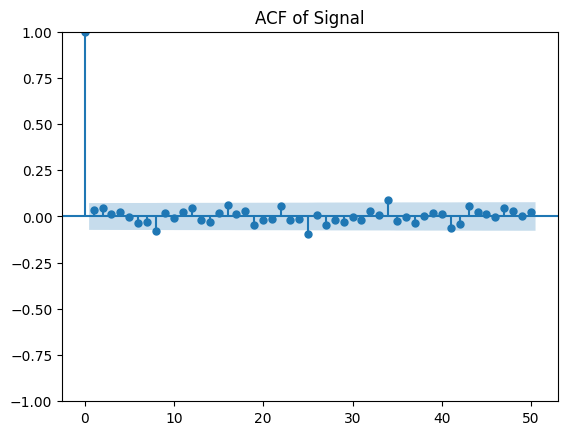

<Figure size 1200x500 with 0 Axes>

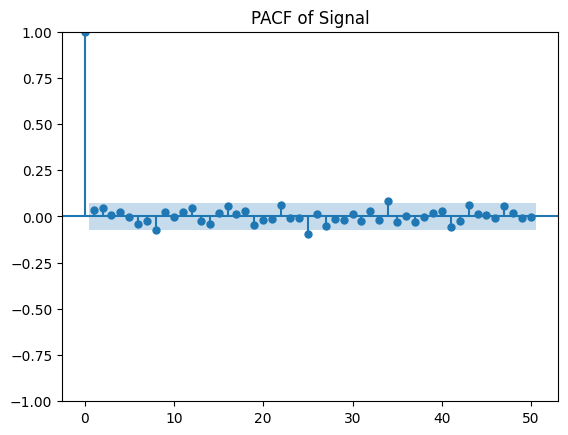

In [23]:
# now time to perform the acf , pacf test on df

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(df["signal"], lags=50)
plt.title("ACF of Signal")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df["signal"], lags=50)
plt.title("PACF of Signal")
plt.show()

# based on these values the previous value barely has any affect so autocorrelation isn't valued much here

In [24]:
# model training and storage 

model = RandomForestClassifier()
scaler = StandardScaler()
df
df.columns
X = df[['ma5_smooth_signal', 'ret_5d', 'vol_50d','vix_level', 'vol_20d', 'ret_1d', 'close_vs_ma5', 'high_low_range','dow', 'ret_overnight', 'momentum_5_20', 'ret_zscore']]
df.columns
y = df['target']
print(len(y))

# y = np.where(df['target']>0,1,0)
y = df["target"].copy()
y = y.replace(-1, 0)
print(len(y))

727
727


In [25]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [30]:
# ml training and testing 

# model = RandomForestClassifier()
params = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 1,
    "min_child_weight": 5,
    "reg_alpha": 0.1,   
    "reg_lambda": 1.0,  
    "random_state": 1312,
    "n_jobs": -1
}
model = XGBClassifier(**params)
scaler = StandardScaler()


scaler.fit_transform(X_train)
scaler.transform(X_test)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

acc_score = accuracy_score(y_test,y_pred)
acc_score

0.4863013698630137

In [31]:
from sklearn.metrics import confusion_matrix

m = confusion_matrix(y_test,y_pred)
print(m)

[[37 27]
 [48 34]]


In [32]:
df_bt = df.iloc[split_idx:].copy()

df_bt["y_pred"] = y_pred

In [33]:
df_bt = df_bt.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
})

In [34]:
class EmaXgboost(Strategy):

    def init(self):
        pass  # already have ema50 in data

    def next(self):
        price = self.data.Close[-1]
        ema   = self.data.ema50[-1]
        pred  = self.data.y_pred[-1]

        # BUY condition
        if pred == 1 and price > ema:
            if not self.position:
                self.buy()

        # SELL condition
        elif pred == 0 and price < ema:
            if self.position:
                self.position.close()
                self.sell()

if __name__ == "__main__":
    bt = Backtest(data=df_bt,strategy=EmaXgboost,cash=10000000)
    stats = bt.run()
    print(stats)

Backtest.run:   0%|          | 0/145 [00:00<?, ?bar/s]

Start                                   840.0
End                                     985.0
Duration                                145.0
Exposure Time [%]                    57.53425
Equity Final [$]                9408852.40234
Equity Peak [$]                10447751.85547
Return [%]                           -5.91148
Buy & Hold Return [%]                 5.84553
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              0.0
Alpha [%]                            -3.92317
Beta                                 -0.34014
Max. Drawdown [%]                   -11.02832
Avg. Drawdown [%]                    -4.22025
Max. Drawdown Duration                   83.0
Avg. Drawdown Duration                   34.5
# Trades                                 21.0
Win Rate [%]                         52.38095
Best Trade [%]                    

In [36]:
"""
pipeline.py
Full end-to-end pipeline: feature engineering → walk-forward validation → backtest
Run BEFORE mlflow_logger.py (this saves artifacts that logger picks up)
"""

import pandas as pd
import numpy as np
import warnings, os, json, pickle
warnings.filterwarnings("ignore")

from ta.momentum import RSIIndicator
from ta.trend    import EMAIndicator
from xgboost     import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix)
from backtesting import Backtest, Strategy

# ─────────────────────────────────────────────
# 0. PATHS  (edit only these)
# ─────────────────────────────────────────────
BASE   = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv"
OUT    = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship"

BANK_NIFTY_PATH      = os.path.join(BASE, "banknifty.csv")
INDIAVIX_PATH        = os.path.join(BASE, "indiavix.csv")
NIFTY50_PATH         = os.path.join(BASE, "nifty50.csv")
STARTER_FEAT_PATH    = os.path.join(BASE, "starter_features.csv")
ARTIFACTS_DIR        = os.path.join(OUT,  "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Out-of-sample boundary (do NOT tune on OOS)
OOS_START = "2025-07-01"

# ─────────────────────────────────────────────
# 1. LOAD RAW DATA
# ─────────────────────────────────────────────
def load_raw():
    def _load(path):
        df = pd.read_csv(path, parse_dates=["date"])
        df.columns = df.columns.str.strip().str.lower()
        return df.sort_values("date").reset_index(drop=True)

    nifty = _load(NIFTY50_PATH)
    bn    = _load(BANK_NIFTY_PATH)
    vix   = _load(INDIAVIX_PATH)
    sf    = _load(STARTER_FEAT_PATH)
    return nifty, bn, vix, sf

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING  (all features are EOD-T safe)
# ─────────────────────────────────────────────
def build_features(nifty: pd.DataFrame,
                   bn:    pd.DataFrame,
                   vix:   pd.DataFrame) -> pd.DataFrame:
    df = nifty.copy()

    # ── NIFTY price features ──────────────────
    df["ret_1d"]        = df["close"].pct_change(1)
    df["ret_5d"]        = df["close"].pct_change(5)
    df["ret_overnight"] = (df["open"] - df["close"].shift(1)) / df["close"].shift(1)
    df["high_low_range"]= (df["high"] - df["low"]) / df["low"]

    for w in [5, 20, 50]:
        df[f"ma{w}"] = df["close"].rolling(w).mean()

    df["close_vs_ma5"]     = (df["close"] - df["ma5"])  / df["ma5"]
    df["ma5_smooth_signal"]= (df["ma5"] - df["ma5"].shift(1)) / df["close"].shift(1)
    df["momentum_5_20"]    = df["ret_5d"] - df["close"].pct_change(20)

    log_ret = np.log(df["close"] / df["close"].shift(1))
    df["vol_20d"]  = log_ret.rolling(20).std()
    df["vol_50d"]  = log_ret.rolling(50).std()

    df["rsi_14"]   = RSIIndicator(close=df["close"], window=14).rsi()
    df["ret_zscore"]= (df["ret_1d"] - df["ret_1d"].rolling(20).mean()) / df["ret_1d"].rolling(20).std()
    df["dow"]       = df["date"].dt.dayofweek

    # ── VIX features ──────────────────────────
    vix = vix.copy()
    vix["vix_level"]  = vix["close"]
    vix["vix_change"] = vix["close"].pct_change(1)
    df = df.merge(vix[["date", "vix_level", "vix_change"]], on="date", how="left")

    # ── BankNifty cross-asset ──────────────────
    bn = bn.copy()
    bn["bn_ret_1d"] = bn["close"].pct_change(1)
    df = df.merge(bn[["date", "bn_ret_1d"]], on="date", how="left")

    # ── TARGET  (shift -1 → next day direction) ──
    df["target"] = np.where(df["close"].pct_change(1).shift(-1) > 0, 1, 0)

    # drop helper cols
    df.drop(columns=["ma5", "ma20", "ma50"], inplace=True, errors="ignore")
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# Final 12 features  (all computable at EOD-T, zero lookahead)
FEATURES = [
    "ret_1d",           # 1-day return at close T
    "ret_5d",           # 5-day momentum
    "ret_overnight",    # gap open signal
    "high_low_range",   # intraday range (T)
    "close_vs_ma5",     # price vs 5-day MA
    "ma5_smooth_signal",# MA slope
    "momentum_5_20",    # fast vs slow momentum
    "vol_20d",          # 20-day realised vol
    "vol_50d",          # 50-day realised vol
    "rsi_14",           # RSI
    "vix_level",        # India VIX at close T
    "vix_change",       # VIX 1-day change
]

# ─────────────────────────────────────────────
# 3. WALK-FORWARD VALIDATION  (in-sample only)
# ─────────────────────────────────────────────
def walk_forward(df_is: pd.DataFrame):
    """
    Expanding-window walk-forward on in-sample data.
    Train: first N days  |  Val: next 63 trading days (~1 quarter)
    Step : 63 days
    """
    STEP      = 63   # 1-quarter step
    MIN_TRAIN = 252  # need at least 1 year to start

    X = df_is[FEATURES].values
    y = df_is["target"].values

    fold_results = []
    fold_models  = []
    start = MIN_TRAIN

    while start + STEP <= len(df_is):
        X_tr, y_tr = X[:start],          y[:start]
        X_va, y_va = X[start:start+STEP], y[start:start+STEP]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_va_s = scaler.transform(X_va)

        params = {
            "n_estimators": 300, "max_depth": 4, "learning_rate": 0.03,
            "subsample": 0.8, "colsample_bytree": 0.8, "gamma": 1,
            "min_child_weight": 5, "reg_alpha": 0.1, "reg_lambda": 1.0,
            "random_state": 42, "n_jobs": -1, "use_label_encoder": False,
            "eval_metric": "logloss"
        }
        mdl = XGBClassifier(**params)
        mdl.fit(X_tr_s, y_tr)

        preds = mdl.predict(X_va_s)
        proba = mdl.predict_proba(X_va_s)[:, 1]
        fold_results.append({
            "fold":      len(fold_results) + 1,
            "train_end": df_is["date"].iloc[start - 1],
            "val_start": df_is["date"].iloc[start],
            "val_end":   df_is["date"].iloc[min(start + STEP - 1, len(df_is) - 1)],
            "auc":       roc_auc_score(y_va, proba),
            "bal_acc":   balanced_accuracy_score(y_va, preds),
            "acc":       accuracy_score(y_va, preds),
        })
        fold_models.append((scaler, mdl))
        start += STEP

    return pd.DataFrame(fold_results), fold_models


# ─────────────────────────────────────────────
# 4. FINAL MODEL  (retrain on full in-sample)
# ─────────────────────────────────────────────
def train_final_model(df_is: pd.DataFrame):
    X = df_is[FEATURES].values
    y = df_is["target"].values
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    params = {
        "n_estimators": 300, "max_depth": 4, "learning_rate": 0.03,
        "subsample": 0.8, "colsample_bytree": 0.8, "gamma": 1,
        "min_child_weight": 5, "reg_alpha": 0.1, "reg_lambda": 1.0,
        "random_state": 42, "n_jobs": -1, "use_label_encoder": False,
        "eval_metric": "logloss"
    }
    mdl = XGBClassifier(**params)
    mdl.fit(X_s, y)
    return scaler, mdl


# ─────────────────────────────────────────────
# 5. OOS EVALUATION
# ─────────────────────────────────────────────
def evaluate_oos(df_oos, scaler, model):
    X_oos = scaler.transform(df_oos[FEATURES].values)
    y_oos = df_oos["target"].values
    preds = model.predict(X_oos)
    proba = model.predict_proba(X_oos)[:, 1]

    # Bootstrap CIs (1000 samples)
    rng   = np.random.default_rng(42)
    n     = len(y_oos)
    aucs, baccs = [], []
    for _ in range(1000):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_oos[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_oos[idx], proba[idx]))
        baccs.append(balanced_accuracy_score(y_oos[idx], preds[idx]))

    metrics = {
        "auc_mean":      float(np.mean(aucs)),
        "auc_ci_lo":     float(np.percentile(aucs, 2.5)),
        "auc_ci_hi":     float(np.percentile(aucs, 97.5)),
        "bal_acc_mean":  float(np.mean(baccs)),
        "bal_acc_ci_lo": float(np.percentile(baccs, 2.5)),
        "bal_acc_ci_hi": float(np.percentile(baccs, 97.5)),
        "confusion_matrix": confusion_matrix(y_oos, preds).tolist(),
    }
    df_oos = df_oos.copy()
    df_oos["y_pred"] = preds
    return metrics, df_oos


# ─────────────────────────────────────────────
# 6. BACKTEST  (using backtesting.py)
# ─────────────────────────────────────────────
def run_backtest(df_oos_with_pred):
    df_bt = df_oos_with_pred[["date", "open", "high", "low", "close", "volume",
                               "ema50" if "ema50" in df_oos_with_pred.columns else "close",
                               "y_pred"]].copy()
    df_bt = df_bt.rename(columns={
        "date": "Date", "open": "Open", "high": "High",
        "low": "Low", "close": "Close", "volume": "Volume"
    })
    if "ema50" not in df_bt.columns:
        df_bt["ema50"] = df_bt["Close"].ewm(span=50).mean()
    df_bt = df_bt.set_index("Date")

    class EmaXgboost(Strategy):
        def init(self):
            self.ema   = self.I(lambda x: x, self.data.ema50)
            self.signal= self.I(lambda x: x, self.data.y_pred)

        def next(self):
            price = self.data.Close[-1]
            ema   = self.ema[-1]
            pred  = self.signal[-1]
            if pred == 1 and price > ema:
                if not self.position:
                    self.buy()
            elif pred == 0 and price < ema:
                if self.position:
                    self.position.close()

    bt    = Backtest(df_bt, EmaXgboost, cash=10_000_000, commission=0.0002)
    stats = bt.run()
    return stats


# ─────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("── Loading data ──")
    nifty, bn, vix, sf = load_raw()

    print("── Building features ──")
    df = build_features(nifty, bn, vix)
    df.to_csv(os.path.join(ARTIFACTS_DIR, "features_final.csv"), index=False)
    print(f"   Total rows: {len(df)}  |  Features: {FEATURES}")

    # Split: in-sample vs out-of-sample
    df_is  = df[df["date"] <  OOS_START].copy()
    df_oos = df[df["date"] >= OOS_START].copy()
    print(f"   IS rows: {len(df_is)}  |  OOS rows: {len(df_oos)}")

    print("── Walk-forward validation (IS only) ──")
    fold_df, fold_models = walk_forward(df_is)
    fold_df.to_csv(os.path.join(ARTIFACTS_DIR, "wf_fold_results.csv"), index=False)
    print(fold_df[["fold", "auc", "bal_acc"]].to_string(index=False))

    print("── Training final model on full IS ──")
    scaler, model = train_final_model(df_is)
    pickle.dump(scaler, open(os.path.join(ARTIFACTS_DIR, "scaler.pkl"), "wb"))
    pickle.dump(model,  open(os.path.join(ARTIFACTS_DIR, "model.pkl"),  "wb"))

    print("── OOS evaluation ──")
    oos_metrics, df_oos_pred = evaluate_oos(df_oos, scaler, model)
    with open(os.path.join(ARTIFACTS_DIR, "oos_metrics.json"), "w") as f:
        json.dump(oos_metrics, f, indent=2)
    df_oos_pred.to_csv(os.path.join(ARTIFACTS_DIR, "oos_predictions.csv"), index=False)
    print(json.dumps(oos_metrics, indent=2))

    # Add ema50 to OOS df for backtest
    df_oos_pred["ema50"] = df_oos_pred["close"].ewm(span=50).mean()

    print("── Backtest ──")
    stats = run_backtest(df_oos_pred)
    bt_metrics = {
        "sharpe":       float(stats["Sharpe Ratio"]),
        "max_drawdown": float(stats["Max. Drawdown [%]"]),
        "hit_rate":     float(stats["Win Rate [%]"]),
        "return_pct":   float(stats["Return [%]"]),
        "num_trades":   int(stats["# Trades"]),
    }
    with open(os.path.join(ARTIFACTS_DIR, "backtest_metrics.json"), "w") as f:
        json.dump(bt_metrics, f, indent=2)
    print(json.dumps(bt_metrics, indent=2))
    print("\n✓ All artifacts saved to:", ARTIFACTS_DIR)

── Loading data ──
── Building features ──
   Total rows: 933  |  Features: ['ret_1d', 'ret_5d', 'ret_overnight', 'high_low_range', 'close_vs_ma5', 'ma5_smooth_signal', 'momentum_5_20', 'vol_20d', 'vol_50d', 'rsi_14', 'vix_level', 'vix_change']
   IS rows: 807  |  OOS rows: 126
── Walk-forward validation (IS only) ──
 fold      auc  bal_acc
    1 0.525499 0.553769
    2 0.478261 0.496196
    3 0.594595 0.528067
    4 0.398947 0.403684
    5 0.375260 0.408524
    6 0.452632 0.456316
    7 0.528261 0.460326
    8 0.489899 0.509091
── Training final model on full IS ──
── OOS evaluation ──
{
  "auc_mean": 0.5692701456359399,
  "auc_ci_lo": 0.47187285051014555,
  "auc_ci_hi": 0.6714527832579895,
  "bal_acc_mean": 0.5664426215990702,
  "bal_acc_ci_lo": 0.49721635679126475,
  "bal_acc_ci_hi": 0.6303072983354673,
  "confusion_matrix": [
    [
      17,
      45
    ],
    [
      9,
      55
    ]
  ]
}
── Backtest ──


Backtest.run:   0%|          | 0/125 [00:00<?, ?bar/s]

{
  "sharpe": 1.175850915866799,
  "max_drawdown": -2.566139770554965,
  "hit_rate": 50.0,
  "return_pct": 3.577720337343756,
  "num_trades": 2
}

✓ All artifacts saved to: C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\artifacts


In [231]:
!pip install mlflow

  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached opentelemetry_api-1.41.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached opentelemetry_sdk-1.41.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached graphql_core-3.2.8-py3-none-any.whl.metadata (11 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached opentelemetry_semantic_conventions-0.62b1-py3-none-any.whl.metadata (2.5 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
   ---------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 6.33.6 which is incompatible.
orbax-checkpoint 0.6.4 requires jax>=0.4.26, but you have jax 0.4.23 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf<4.22,>=4.21.6; python_version < "3.11", but you have protobuf 6.33.6 which is incompatible.


In [233]:
pip install --upgrade mlflow

Note: you may need to restart the kernel to use updated packages.


In [235]:
"""
mlflow_logger.py
Reads artifacts produced by pipeline.py and logs everything to MLflow.
Run AFTER pipeline.py is complete.
"""

import os, json, pickle
import pandas as pd
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature

# ─────────────────────────────────────────────
# PATHS  (edit only these)
# ─────────────────────────────────────────────
ARTIFACTS_DIR = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\artifacts"
MLFLOW_DB     = r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\mlflow.db"

FEATURES = [
    "ret_1d", "ret_5d", "ret_overnight", "high_low_range",
    "close_vs_ma5", "ma5_smooth_signal", "momentum_5_20",
    "vol_20d", "vol_50d", "rsi_14", "vix_level", "vix_change",
]

# ─────────────────────────────────────────────
# CONNECT TO LOCAL MLFLOW DB
# ─────────────────────────────────────────────
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment("nifty_direction_classifier")

# ─────────────────────────────────────────────
# LOAD ARTIFACTS
# ─────────────────────────────────────────────
def load_artifacts():
    scaler      = pickle.load(open(os.path.join(ARTIFACTS_DIR, "scaler.pkl"), "rb"))
    model       = pickle.load(open(os.path.join(ARTIFACTS_DIR, "model.pkl"),  "rb"))
    oos_metrics = json.load(open(os.path.join(ARTIFACTS_DIR, "oos_metrics.json")))
    bt_metrics  = json.load(open(os.path.join(ARTIFACTS_DIR, "backtest_metrics.json")))
    fold_df     = pd.read_csv(os.path.join(ARTIFACTS_DIR, "wf_fold_results.csv"))
    df_oos      = pd.read_csv(os.path.join(ARTIFACTS_DIR, "oos_predictions.csv"),
                              parse_dates=["date"])
    return scaler, model, oos_metrics, bt_metrics, fold_df, df_oos


# ─────────────────────────────────────────────
# LOG WALK-FORWARD FOLDS  (one run per fold)
# ─────────────────────────────────────────────
def log_folds(fold_df: pd.DataFrame):
    print("Logging walk-forward folds…")
    for _, row in fold_df.iterrows():
        with mlflow.start_run(run_name=f"wf_fold_{int(row['fold'])}", nested=True):
            mlflow.log_param("fold",       int(row["fold"]))
            mlflow.log_param("train_end",  str(row["train_end"]))
            mlflow.log_param("val_start",  str(row["val_start"]))
            mlflow.log_param("val_end",    str(row["val_end"]))
            mlflow.log_metric("auc",       row["auc"])
            mlflow.log_metric("bal_acc",   row["bal_acc"])
            mlflow.log_metric("acc",       row["acc"])
    print(f"  ✓ {len(fold_df)} folds logged")


# ─────────────────────────────────────────────
# LOG FINAL RUN
# ─────────────────────────────────────────────
def log_final_run(scaler, model, oos_metrics, bt_metrics, fold_df, df_oos):
    print("Logging final run…")
    with mlflow.start_run(run_name="final_model_oos_eval") as run:

        # ── Params ───────────────────────────
        xgb_params = model.get_params()
        for k, v in xgb_params.items():
            mlflow.log_param(k, v)
        mlflow.log_param("features",        FEATURES)
        mlflow.log_param("n_features",      len(FEATURES))
        mlflow.log_param("oos_start",       "2025-07-01")
        mlflow.log_param("oos_end",         "2025-12-31")
        mlflow.log_param("wf_step_days",    63)
        mlflow.log_param("wf_min_train",    252)

        # ── OOS metrics ──────────────────────
        mlflow.log_metric("oos_auc_mean",      oos_metrics["auc_mean"])
        mlflow.log_metric("oos_auc_ci_lo",     oos_metrics["auc_ci_lo"])
        mlflow.log_metric("oos_auc_ci_hi",     oos_metrics["auc_ci_hi"])
        mlflow.log_metric("oos_bal_acc_mean",  oos_metrics["bal_acc_mean"])
        mlflow.log_metric("oos_bal_acc_ci_lo", oos_metrics["bal_acc_ci_lo"])
        mlflow.log_metric("oos_bal_acc_ci_hi", oos_metrics["bal_acc_ci_hi"])

        # ── Backtest metrics ─────────────────
        mlflow.log_metric("bt_sharpe",       bt_metrics["sharpe"])
        mlflow.log_metric("bt_max_drawdown", bt_metrics["max_drawdown"])
        mlflow.log_metric("bt_hit_rate",     bt_metrics["hit_rate"])
        mlflow.log_metric("bt_return_pct",   bt_metrics["return_pct"])
        mlflow.log_metric("bt_num_trades",   bt_metrics["num_trades"])

        # ── Walk-forward aggregate ────────────
        mlflow.log_metric("wf_mean_auc",     fold_df["auc"].mean())
        mlflow.log_metric("wf_std_auc",      fold_df["auc"].std())
        mlflow.log_metric("wf_mean_bal_acc", fold_df["bal_acc"].mean())
        mlflow.log_metric("wf_n_folds",      len(fold_df))

        # ── Log the XGBoost model with signature ──
        X_sample = df_oos[FEATURES].head(5)
        X_scaled = scaler.transform(X_sample)
        sig = infer_signature(X_scaled, model.predict(X_scaled))
        mlflow.xgboost.log_model(model, artifact_path="xgb_model", signature=sig)

        # ── Log raw artifact files ────────────
        mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "scaler.pkl"),           "artifacts")
        mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "oos_metrics.json"),     "artifacts")
        mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "backtest_metrics.json"),"artifacts")
        mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "wf_fold_results.csv"),  "artifacts")
        mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "oos_predictions.csv"),  "artifacts")
        mlflow.log_artifact(os.path.join(ARTIFACTS_DIR, "features_final.csv"),   "artifacts")

        print(f"  ✓ Run ID: {run.info.run_id}")
        print(f"  ✓ Experiment: nifty_direction_classifier")
        print(f"  ✓ Tracking DB: {MLFLOW_DB}")

        # ── Nested fold runs ─────────────────
        log_folds(fold_df)

    print("\n✓ MLflow logging complete.")
    print(f"  View UI: mlflow ui --backend-store-uri sqlite:///{MLFLOW_DB}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    scaler, model, oos_metrics, bt_metrics, fold_df, df_oos = load_artifacts()
    log_final_run(scaler, model, oos_metrics, bt_metrics, fold_df, df_oos)

2026/05/06 23:01:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 23:01:14 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


CommandError: Can't locate revision identified by '7d34483879f0'

In [39]:
# using a simple linear model and seeing what weights and importance is being given to them 

from sklearn.metrics import accuracy_score,precision_score,confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\nifty50.csv")
df2 = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\banknifty.csv")
df3 = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\indiavix.csv")
df4 = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\starter_features.csv")

df = df1.merge(df4,on='date')
df.dropna()

,date,Adj Close,Close,High,Low,Open,Volume,ret_1d,ret_5d,ret_10d,...,vix_level,vix_change,vix_5d_change,vix_ma_ratio,close_vs_252d_high,close_vs_252d_low,dow,ret_zscore,ma5_smooth_signal,volume_normalized
251,2023-01-05,17992.150391,17992.150391,18120.300781,17892.599609,18101.949219,269900,-0.002815,-0.010931,-0.007458,...,14.98,-0.014474,0.011479,1.031680,0.956393,1.176457,3,-0.381681,-0.002965,0.250916
252,2023-01-06,17859.449219,17859.449219,18047.400391,17795.550781,18008.050781,238200,-0.007376,-0.013579,0.002957,...,15.03,0.003338,0.010760,1.029628,0.949339,1.167780,4,-0.917097,-0.006814,0.218661
253,2023-01-09,18101.199219,18101.199219,18141.400391,17936.150391,17952.550781,257200,0.013536,-0.005289,0.004807,...,14.65,-0.025283,-0.002723,0.999045,0.962190,1.183588,0,1.538236,0.008281,0.237993
254,2023-01-10,17914.150391,17914.150391,18127.599609,17856.000000,18121.300781,283300,-0.010334,-0.017463,-0.012031,...,15.51,0.058703,0.077832,1.048292,0.952247,1.171357,1,-1.264407,-0.000647,0.264550
255,2023-01-11,17895.699219,17895.699219,17976.349609,17824.349609,17924.250000,259900,-0.001030,-0.008161,-0.012515,...,15.44,-0.004513,0.015789,1.034644,0.951266,1.170151,2,-0.172043,-0.002757,0.240741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,2025-12-22,26172.400391,26172.400391,26180.699219,26047.800781,26055.849609,253000,0.007933,0.005575,0.008160,...,9.68,0.016807,-0.055610,0.898835,0.998354,1.185202,0,0.880374,0.004517,0.233720
982,2025-12-23,26177.150391,26177.150391,26233.550781,26119.050781,26205.199219,216600,0.000181,0.012260,0.013061,...,9.38,-0.030992,-0.067594,0.882699,0.998535,1.185417,1,-0.029800,0.002953,0.196683
983,2025-12-24,26142.099609,26142.099609,26236.400391,26123.000000,26170.650391,188800,-0.001339,0.012532,0.014912,...,9.19,-0.020256,-0.066057,0.876281,0.997198,1.183830,2,-0.208325,0.001797,0.168396
984,2025-12-26,26042.300781,26042.300781,26144.199219,26008.599609,26121.250000,142200,-0.003818,0.008783,0.005551,...,9.15,-0.004353,-0.057673,0.883588,0.993391,1.179310,4,-0.499343,-0.000238,0.120981


In [61]:
df['signal_strength'] = (df['Close'] - df['Close'].shift(1))
df['signal'] = np.where(df['signal_strength']>0,1,0)

In [62]:
df.dropna(inplace=True)
df

,date,Adj Close,Close,High,Low,Open,Volume,ret_1d,ret_5d,ret_10d,...,vix_5d_change,vix_ma_ratio,close_vs_252d_high,close_vs_252d_low,dow,ret_zscore,ma5_smooth_signal,volume_normalized,signal,signal_strength
253,2023-01-09,18101.199219,18101.199219,18141.400391,17936.150391,17952.550781,257200,0.013536,-0.005289,0.004807,...,-0.002723,0.999045,0.962190,1.183588,0,1.538236,0.008281,0.237993,1,241.750000
254,2023-01-10,17914.150391,17914.150391,18127.599609,17856.000000,18121.300781,283300,-0.010334,-0.017463,-0.012031,...,0.077832,1.048292,0.952247,1.171357,1,-1.264407,-0.000647,0.264550,0,-187.048828
255,2023-01-11,17895.699219,17895.699219,17976.349609,17824.349609,17924.250000,259900,-0.001030,-0.008161,-0.012515,...,0.015789,1.034644,0.951266,1.170151,2,-0.172043,-0.002757,0.240741,0,-18.451172
256,2023-01-12,17858.199219,17858.199219,17945.800781,17761.650391,17920.849609,227800,-0.002095,-0.007445,-0.018295,...,0.020027,1.018633,0.949273,1.167699,3,-0.297147,-0.002553,0.208079,0,-37.500000
257,2023-01-13,17956.599609,17956.599609,17999.349609,17774.250000,17867.500000,256700,0.005510,0.005440,-0.008213,...,-0.037924,0.962716,0.954504,1.174133,4,0.595853,0.001387,0.237485,1,98.400391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,2025-12-22,26172.400391,26172.400391,26180.699219,26047.800781,26055.849609,253000,0.007933,0.005575,0.008160,...,-0.055610,0.898835,0.998354,1.185202,0,0.880374,0.004517,0.233720,1,206.000000
982,2025-12-23,26177.150391,26177.150391,26233.550781,26119.050781,26205.199219,216600,0.000181,0.012260,0.013061,...,-0.067594,0.882699,0.998535,1.185417,1,-0.029800,0.002953,0.196683,1,4.750000
983,2025-12-24,26142.099609,26142.099609,26236.400391,26123.000000,26170.650391,188800,-0.001339,0.012532,0.014912,...,-0.066057,0.876281,0.997198,1.183830,2,-0.208325,0.001797,0.168396,0,-35.050781
984,2025-12-26,26042.300781,26042.300781,26144.199219,26008.599609,26121.250000,142200,-0.003818,0.008783,0.005551,...,-0.057673,0.883588,0.993391,1.179310,4,-0.499343,-0.000238,0.120981,0,-99.798828


In [93]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

df1 = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\nifty50.csv")
df4 = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\Workstation\Internship\data\csv\starter_features.csv")

df = df1.merge(df4, on='date')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df['future_close'] = df['Close'].shift(-1)
df['signal'] = (df['future_close'] > df['Close']).astype(int)

df = df.dropna().reset_index(drop=True)

features = [
    'ret_1d','ret_5d','ret_10d','ret_20d',
    'ret_intraday','ret_overnight',
    'high_low_range','log_volume','volume_ratio_20d',
    'close_vs_ma5','close_vs_ma20','close_vs_ma50',
    'momentum_5_20','vol_5d','vol_20d','vol_50d',
    'rsi_14','bn_ret_1d','bn_ret_5d',
    'nifty_bn_spread','nifty_bn_corr_20d',
    'vix_level','vix_change','vix_5d_change',
    'vix_ma_ratio','close_vs_252d_high','close_vs_252d_low',
    'dow','ret_zscore','ma5_smooth_signal','volume_normalized'
]

X = df[features]
y = df['signal']

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(y_pred)

0.7322834645669292
[0 0 1 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 0 1 0 1 0 1 1 1 1
 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 1
 0 0 1 1 1 0 1 1 1 1 1 0 1 0 1 1]


In [85]:
model

DecisionTreeClassifier()

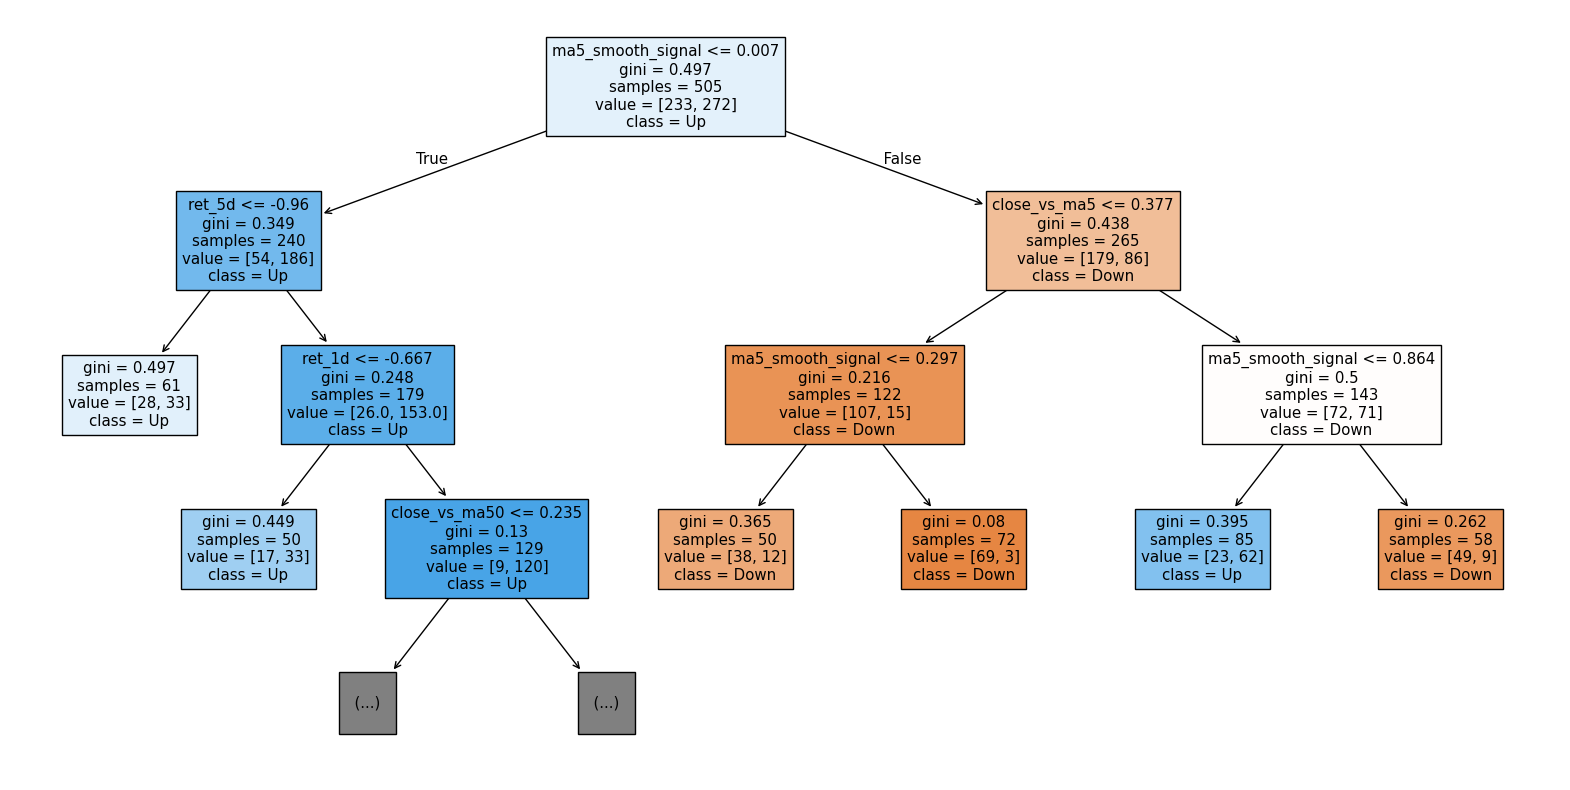

In [94]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=X.columns,
          class_names=["Down","Up"],
          filled=True,
          max_depth=3)
plt.show()

In [95]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print(importances)


=== FEATURE IMPORTANCE ===
ma5_smooth_signal     0.691697
close_vs_ma5          0.166844
ret_5d                0.081346
ret_1d                0.047790
close_vs_ma50         0.012324
nifty_bn_spread       0.000000
nifty_bn_corr_20d     0.000000
vix_level             0.000000
vix_change            0.000000
vix_5d_change         0.000000
bn_ret_1d             0.000000
vix_ma_ratio          0.000000
close_vs_252d_high    0.000000
close_vs_252d_low     0.000000
dow                   0.000000
ret_zscore            0.000000
bn_ret_5d             0.000000
vol_50d               0.000000
rsi_14                0.000000
vol_20d               0.000000
vol_5d                0.000000
momentum_5_20         0.000000
close_vs_ma20         0.000000
volume_ratio_20d      0.000000
log_volume            0.000000
high_low_range        0.000000
ret_overnight         0.000000
ret_intraday          0.000000
ret_20d               0.000000
ret_10d               0.000000
volume_normalized     0.000000
dtype: floa

In [96]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = df.sort_values('date').reset_index(drop=True)

df['future_close'] = df['Close'].shift(-1)
df['signal'] = (df['future_close'] > df['Close']).astype(int)

df = df.dropna().reset_index(drop=True)

features = [
    'ret_1d','ret_5d','ret_10d',
    'ret_20d','ret_intraday','ret_overnight','high_low_range',
    'log_volume','volume_ratio_20d','close_vs_ma5','close_vs_ma20',
    'close_vs_ma50','momentum_5_20','vol_5d','vol_20d','vol_50d',
    'rsi_14','bn_ret_1d','bn_ret_5d','nifty_bn_spread',
    'nifty_bn_corr_20d','vix_level','vix_change','vix_5d_change',
    'vix_ma_ratio','close_vs_252d_high','close_vs_252d_low','dow',
    'ret_zscore','ma5_smooth_signal','volume_normalized'
]

X = df[features]
y = df['signal']

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

probs = model.predict(X_test_s)
y_pred = (probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7952755905511811


In [97]:
importance = pd.Series(model.coef_, index=X.columns)
importance = importance.sort_values()

print("\n=== LINEAR MODEL FEATURE IMPORTANCE (COEFFICIENTS) ===")
print(importance)


=== LINEAR MODEL FEATURE IMPORTANCE (COEFFICIENTS) ===
ret_1d               -2.848283
ret_zscore           -2.848283
bn_ret_1d            -1.882675
nifty_bn_spread      -0.965458
ma5_smooth_signal    -0.485415
volume_normalized    -0.097033
ret_5d               -0.063029
ret_20d              -0.047906
high_low_range       -0.029095
vix_level            -0.024609
vol_50d              -0.023137
vix_5d_change        -0.022666
rsi_14               -0.022277
nifty_bn_corr_20d    -0.020511
close_vs_252d_high   -0.007880
dow                  -0.007215
ret_10d              -0.005279
bn_ret_5d             0.000969
volume_ratio_20d      0.006388
vix_ma_ratio          0.008229
vol_5d                0.010374
vix_change            0.012998
momentum_5_20         0.015133
close_vs_252d_low     0.023360
vol_20d               0.032697
close_vs_ma20         0.063450
log_volume            0.071638
close_vs_ma50         0.075702
close_vs_ma5          0.194621
ret_overnight         4.479049
ret_intraday  

In [98]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

df = df.sort_values('date').reset_index(drop=True)

df['future_close'] = df['Close'].shift(-1)
df['signal'] = (df['future_close'] > df['Close']).astype(int)

df = df.dropna().reset_index(drop=True)

features = [
    'ret_1d','ret_5d','ret_10d',
    'ret_20d','ret_intraday','ret_overnight','high_low_range',
    'log_volume','volume_ratio_20d','close_vs_ma5','close_vs_ma20',
    'close_vs_ma50','momentum_5_20','vol_5d','vol_20d','vol_50d',
    'rsi_14','bn_ret_1d','bn_ret_5d','nifty_bn_spread',
    'nifty_bn_corr_20d','vix_level','vix_change','vix_5d_change',
    'vix_ma_ratio','close_vs_252d_high','close_vs_252d_low','dow',
    'ret_zscore','ma5_smooth_signal','volume_normalized'
]

X = df[features]
y = df['signal']

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7698412698412699


In [99]:
model.get_params

<bound method XGBModel.get_params of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)>

In [100]:
model.feature_importances_

array([0.05974844, 0.03990319, 0.02697141, 0.03303311, 0.0260109 ,
       0.03437585, 0.02638212, 0.02289126, 0.02529164, 0.06575197,
       0.02788004, 0.02774724, 0.01852958, 0.02076014, 0.03394061,
       0.02140359, 0.02366091, 0.03688957, 0.0326126 , 0.02524518,
       0.0288912 , 0.0261697 , 0.02441591, 0.02458907, 0.02050153,
       0.02342936, 0.016455  , 0.02312945, 0.05709613, 0.09587761,
       0.03041573], dtype=float32)